In [1]:
import colorcet as cc
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from context_flux_no.simulations.pde.cubic import CubicFlux2D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField2D

2026-04-24 16:15:38,707 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [2]:
x, y = jnp.linspace(0, 1, 64), jnp.linspace(0, 1, 64)
grf = GaussianRandomField2D(gs.Gaussian(dim=2, var=1, len_scale=0.3))
u0 = grf.sample((x, y), jax.random.key(0))

In [3]:
u0.shape

(64, 64)

In [8]:
cubic_flux = CubicFlux2D(a=-1.0, b=1.0, c=1.0)
sol = cubic_flux.solve(
    lambda xs: grf.sample(xs, jax.random.key(1)),
    ((0, 1), (0, 1)),
    (50, 50),
    (0, 0.5),
    100,
)

In [9]:
sol

<xarray.Dataset> Size: 1MB
Dimensions:  (ic: 1, t: 101, dim: 1, x: 50, y: 50, param: 3)
Coordinates:
  * t        (t) float32 404B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U1 4B 'u'
  * x        (x) float32 200B 0.01 0.03 0.05 0.07 0.09 ... 0.93 0.95 0.97 0.99
  * y        (y) float32 200B 0.01 0.03 0.05 0.07 0.09 ... 0.93 0.95 0.97 0.99
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x, y) float32 1MB -0.7273 -0.643 ... -0.498 -0.4718
    coeffs   (param) float64 24B -1.0 1.0 1.0

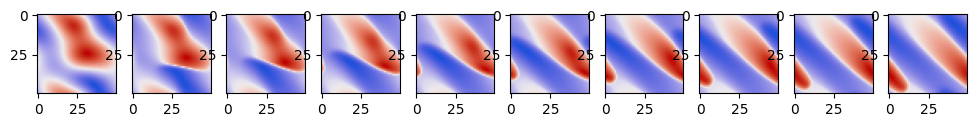

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol["values"][0, i * 10, 0], cmap=cc.cm.coolwarm)

In [11]:
dataset = generate_dataset(
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=CubicFlux2D,
    initial_condition_fn=GaussianRandomField2D(
        gs.Gaussian(dim=2, var=1, len_scale=0.3)
    ).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=((0, 1), (0, 1)),
    Nx=(50, 50),
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)


100%|██████████| 10/10 [01:21<00:00,  8.16s/it]


In [12]:
dataset["values"].nbytes / 1e9

0.101

In [ ]:
def generate_dataset_incremental(
    n_coeffs: int,
    n_ics_per_coeff: int,
    pde_factory: Callable[[Any], eqx.Module],
    initial_condition_fn: Callable[[Array, PRNGKeyArray], Array],
    coeff_range_dict: dict,
    x_span: tuple[float, float],
    Nx: int,
    t_span: tuple[float, float],
    Nt: int,
    bc: Literal["periodic"] = "periodic",
    dataset_type: Literal["train", "validation", "test"] = "train",
    seed: int = 0,
):